In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

df = pd.read_csv("results1000.csv")
print(f"{len(df):,} rows, {df['task'].nunique()} tasks, "
      f"context: {sorted(df['context'].unique())}, "
      f"horizon: {sorted(df['horizon'].unique())}")
df.head()

1,267,731 rows, 1739 tasks, context: [np.int64(0), np.int64(512), np.int64(1024), np.int64(1536), np.int64(2048), np.int64(2560), np.int64(3072), np.int64(3584), np.int64(4096)], horizon: [np.int64(0), np.int64(512), np.int64(1024), np.int64(1536), np.int64(2048), np.int64(2560), np.int64(3072), np.int64(3584), np.int64(4096)]


,context,horizon,step,task,actual,predicted
0,0,0,200,Five standard six-sided dice are rolled. We a...,0.125,0.276691
1,0,0,200,Let $f_1(x) = x^2 - 3$ and $f_n(x) = f_1(f_{n-...,0.000,0.249447
2,0,0,200,"Harry, who is incredibly intellectual, needs t...",0.000,0.262842
3,0,0,200,An equilateral triangle with side length $20$ ...,0.000,0.155078
4,0,0,200,"The real numbers $x$, $y$, and $z$ satisfy the...",0.000,0.083890


## MAE Heatmap: Context × Horizon

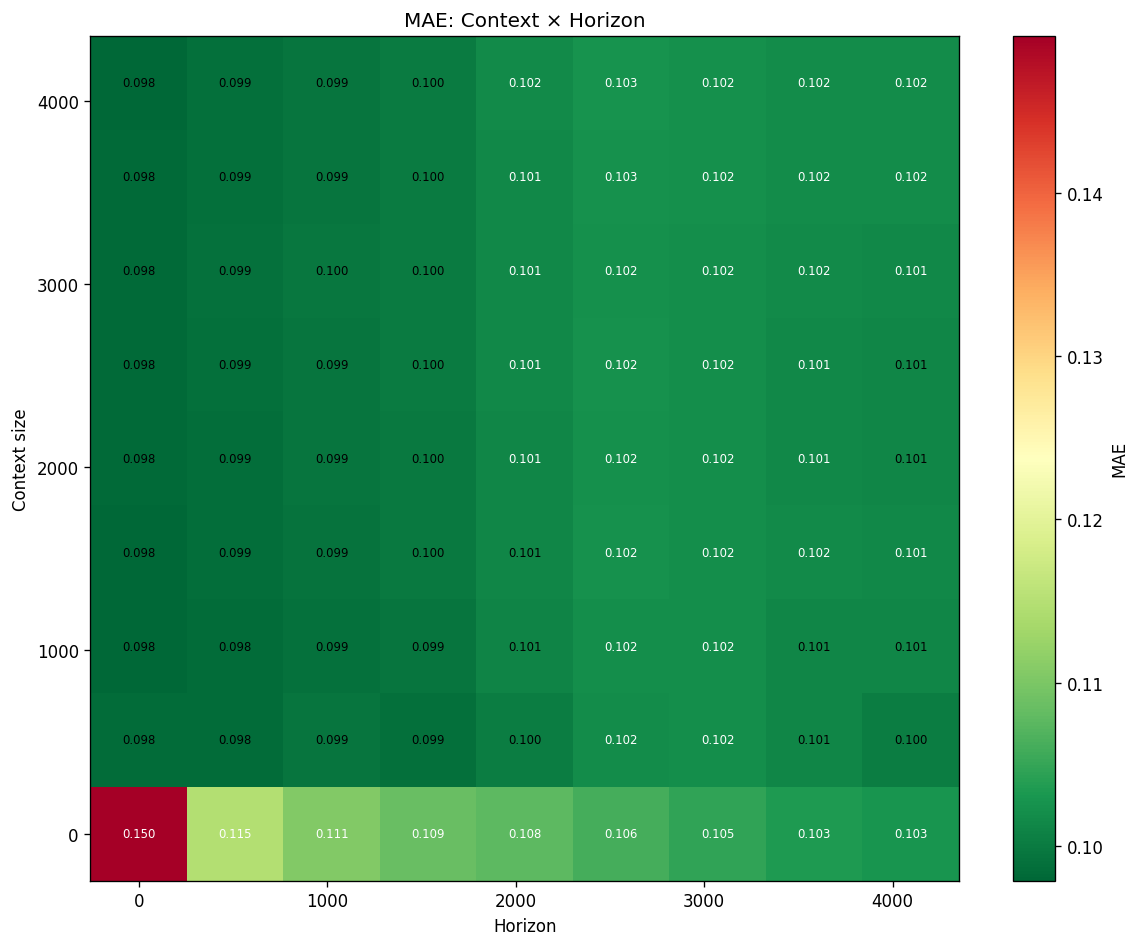

In [8]:
df["error"] = np.abs(df["predicted"] - df["actual"])
mae = df.groupby(["context", "horizon"])["error"].mean().reset_index()
matrix = mae.pivot(index="context", columns="horizon", values="error")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(matrix.columns, matrix.index, matrix.values, cmap="RdYlGn_r", shading="auto")
for i, c in enumerate(matrix.index):
    for j, h in enumerate(matrix.columns):
        val = matrix.loc[c, h]
        if not np.isnan(val):
            ax.text(h, c, f"{val:.3f}", ha="center", va="center", fontsize=7,
                    color="white" if val > np.nanmedian(matrix.values) else "black")
fig.colorbar(im, ax=ax, label="MAE")
ax.set_xlabel("Horizon")
ax.set_ylabel("Context size")
ax.set_title("MAE: Context × Horizon")
fig.tight_layout()

## MAE vs Context (horizon=0) and vs Horizon (context=0)

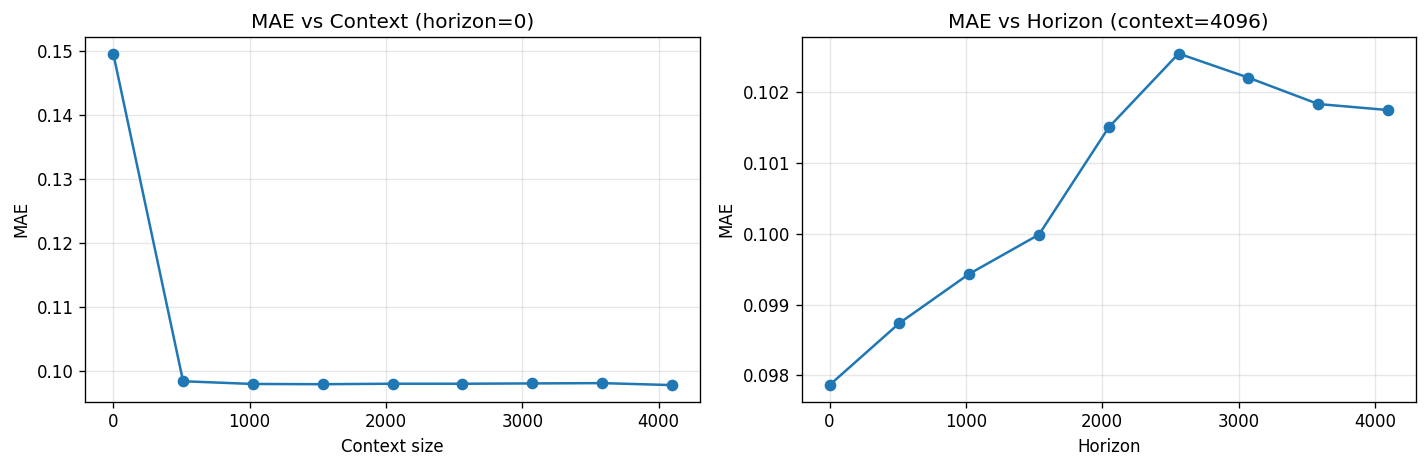

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# MAE vs context (horizon=0)
ctx = df[df["horizon"] == 0].groupby("context")["error"].mean()
ax1.plot(ctx.index, ctx.values, "o-")
ax1.set_xlabel("Context size")
ax1.set_ylabel("MAE")
ax1.set_title("MAE vs Context (horizon=0)")
ax1.grid(alpha=0.3)

# MAE vs horizon (context=0)
hor = df[df["context"] == 4096].groupby("horizon")["error"].mean()
ax2.plot(hor.index, hor.values, "o-")
ax2.set_xlabel("Horizon")
ax2.set_ylabel("MAE")
ax2.set_title("MAE vs Horizon (context=4096)")
ax2.grid(alpha=0.3)

fig.tight_layout()

## Scatter: Predicted vs Actual (selected context sizes, horizon=0)

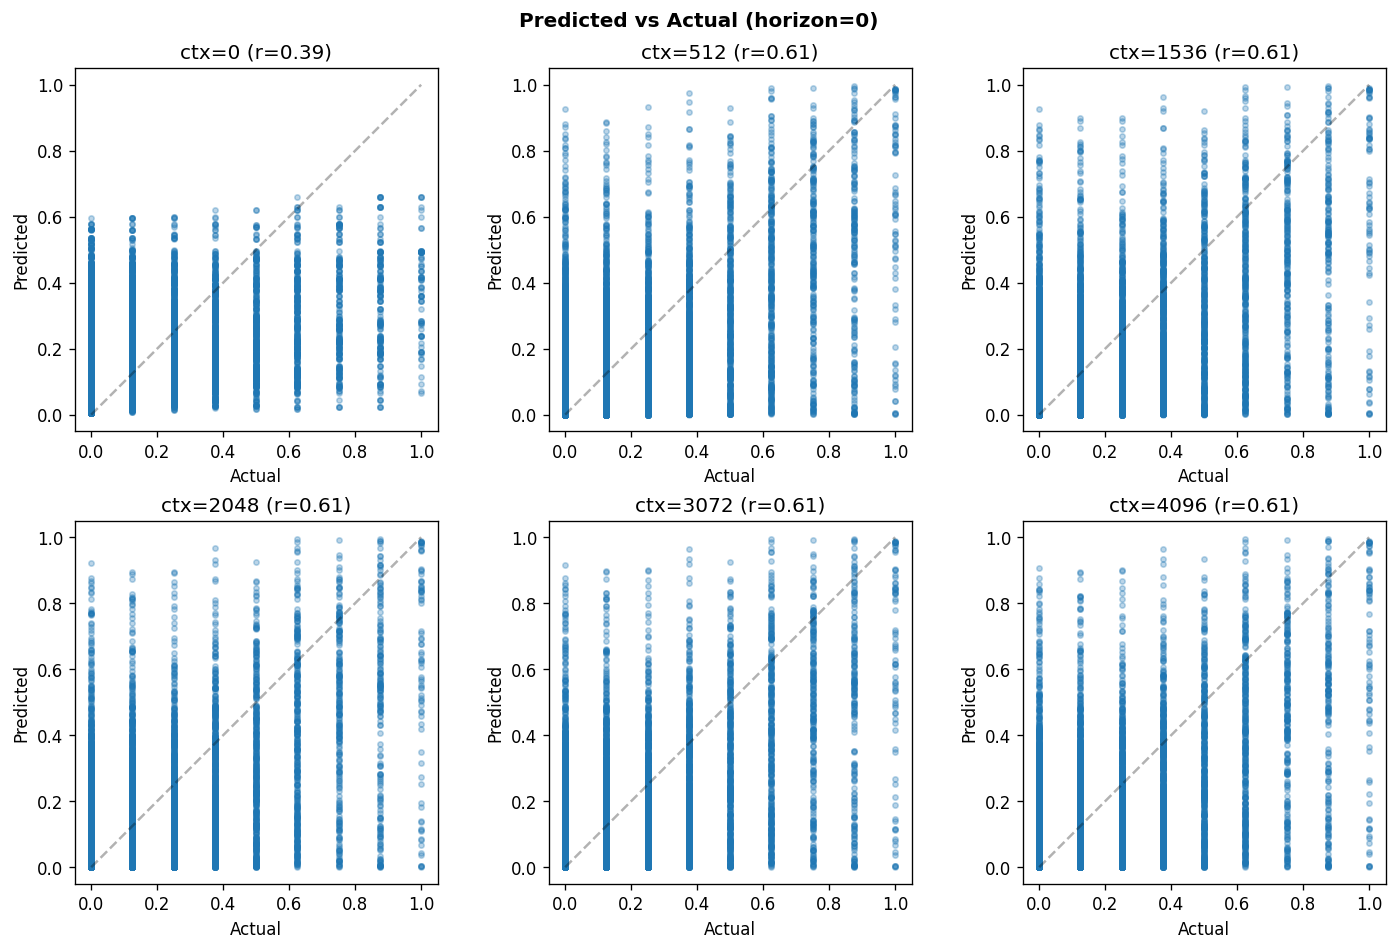

In [10]:
sub = df[df["horizon"] == 0]
contexts = sorted(sub["context"].unique())
# Pick up to 6 evenly spaced context sizes
if len(contexts) > 6:
    idx = np.linspace(0, len(contexts) - 1, 6, dtype=int)
    contexts = [contexts[i] for i in idx]

n = len(contexts)
cols = min(n, 3)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
for i, c in enumerate(contexts):
    ax = axes[i // cols][i % cols]
    d = sub[sub["context"] == c]
    ax.scatter(d["actual"], d["predicted"], alpha=0.3, s=10)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    r = np.corrcoef(d["actual"], d["predicted"])[0, 1]
    ax.set_title(f"ctx={c} (r={r:.2f})")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
for i in range(n, rows * cols):
    axes[i // cols][i % cols].set_visible(False)
fig.suptitle("Predicted vs Actual (horizon=0)", fontweight="bold")
fig.tight_layout()

## Calibration: Binned predicted vs actual mean

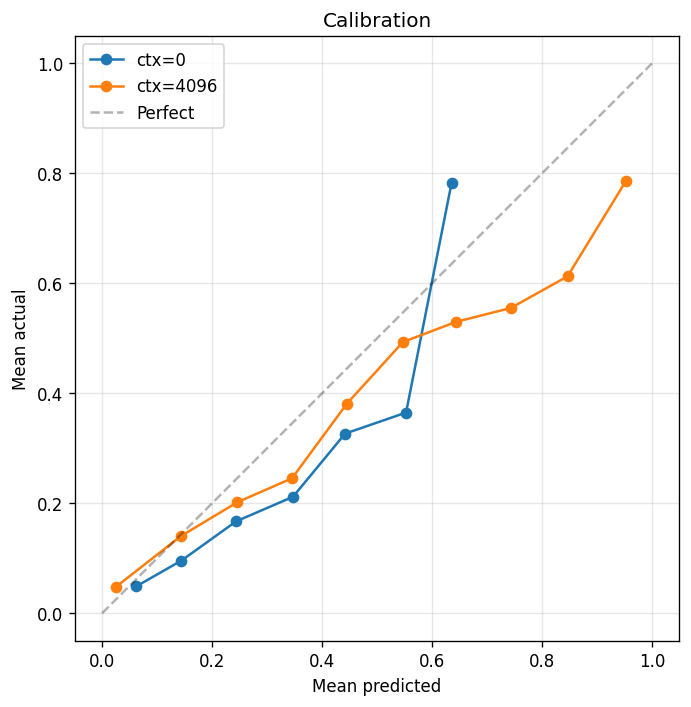

In [11]:
sub = df[df["horizon"] == 0]
contexts = sorted(sub["context"].unique())
max_ctx = contexts[-1]

fig, ax = plt.subplots(figsize=(6, 6))
for c in [0, max_ctx]:
    d = sub[sub["context"] == c]
    bins = np.linspace(0, 1, 11)
    d = d.copy()
    d["bin"] = pd.cut(d["predicted"], bins=bins, include_lowest=True)
    cal = d.groupby("bin", observed=True).agg(
        pred_mean=("predicted", "mean"),
        actual_mean=("actual", "mean"),
        count=("actual", "count"),
    )
    cal = cal[cal["count"] >= 5]
    ax.plot(cal["pred_mean"], cal["actual_mean"], "o-", label=f"ctx={c}", markersize=6)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect")
ax.set_xlabel("Mean predicted")
ax.set_ylabel("Mean actual")
ax.set_title("Calibration")
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
fig.tight_layout()

## Kendall Tau vs Context

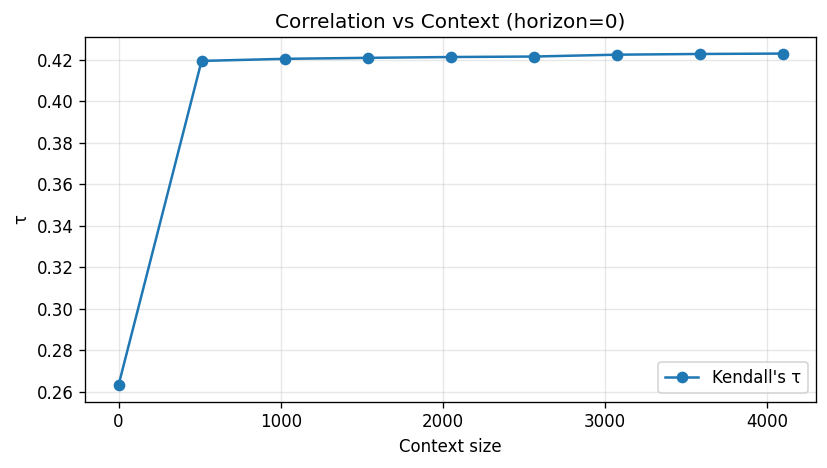

In [12]:
sub = df[df["horizon"] == 0]

tau = []
contexts = sorted(sub["context"].unique())
for c in contexts:
    d = sub[sub["context"] == c]
    tau.append(stats.kendalltau(d["actual"], d["predicted"]).statistic)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(contexts, tau, "o-", label="Kendall's τ")
ax.set_xlabel("Context size")
ax.set_ylabel("τ")
ax.set_title("Correlation vs Context (horizon=0)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

## Error distribution by actual outcome bucket

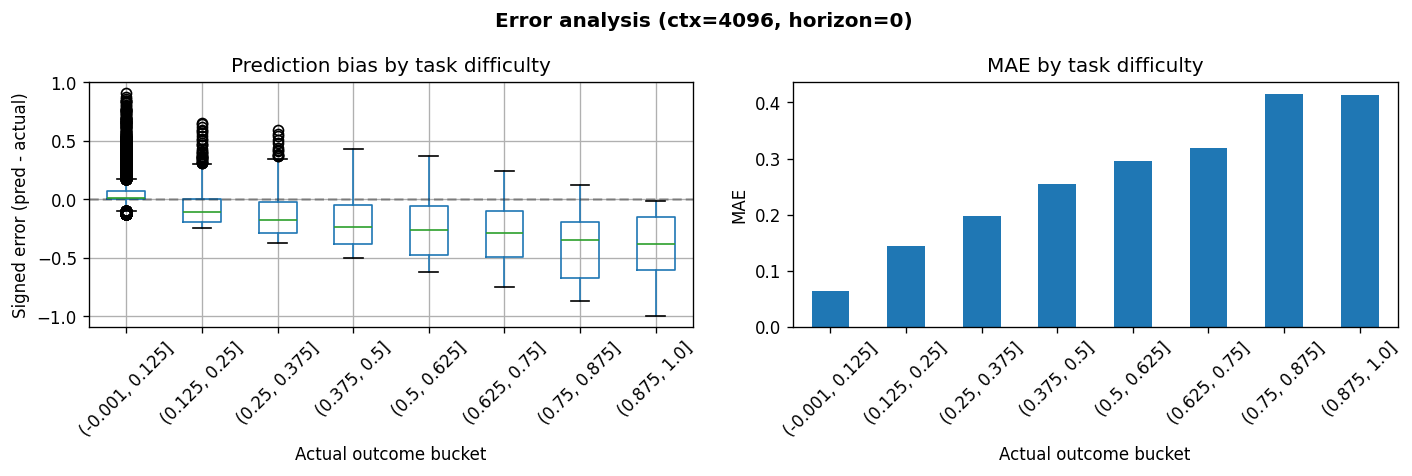

In [13]:
# How does prediction error vary by task difficulty?
sub = df[(df["horizon"] == 0) & (df["context"] == df["context"].max())]
sub = sub.copy()
sub["signed_error"] = sub["predicted"] - sub["actual"]
sub["actual_bin"] = pd.cut(sub["actual"], bins=np.linspace(0, 1, 9), include_lowest=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Signed error by bucket
sub.boxplot(column="signed_error", by="actual_bin", ax=ax1, rot=45)
ax1.axhline(0, color="k", ls="--", alpha=0.3)
ax1.set_xlabel("Actual outcome bucket")
ax1.set_ylabel("Signed error (pred - actual)")
ax1.set_title("Prediction bias by task difficulty")
plt.sca(ax1)
plt.title("Prediction bias by task difficulty")

# MAE by bucket
mae_by_bin = sub.groupby("actual_bin", observed=True)["error"].mean()
mae_by_bin.plot(kind="bar", ax=ax2)
ax2.set_xlabel("Actual outcome bucket")
ax2.set_ylabel("MAE")
ax2.set_title("MAE by task difficulty")
ax2.tick_params(axis="x", rotation=45)

fig.suptitle(f"Error analysis (ctx={int(sub['context'].iloc[0])}, horizon=0)", fontweight="bold")
fig.tight_layout()

## Per-task prediction consistency across context sizes

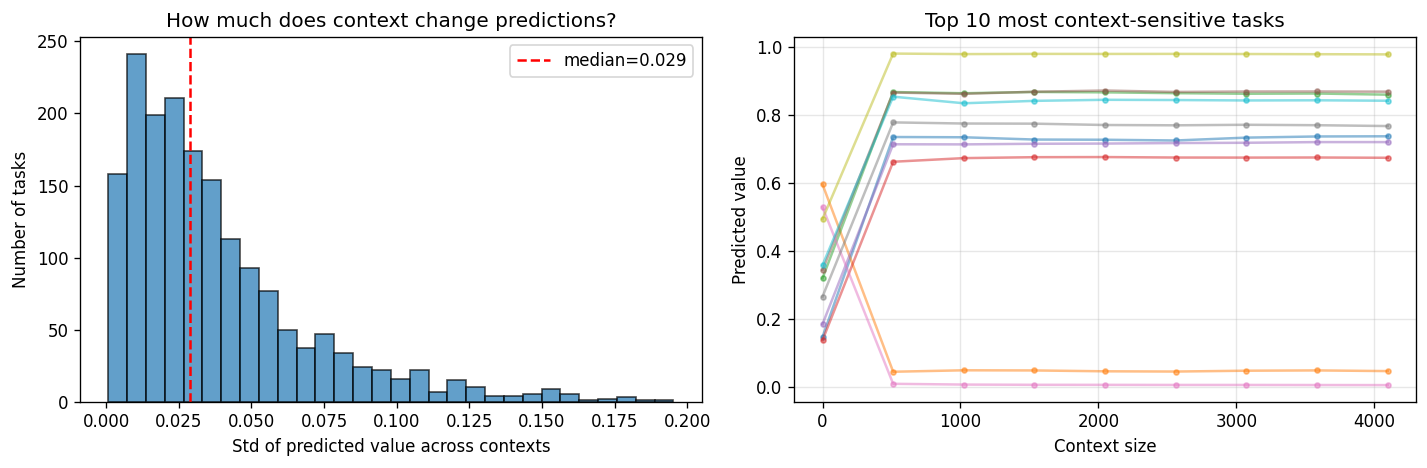

In [14]:
# How much does the prediction for each task change as we add context?
sub = df[df["horizon"] == 0]
task_preds = sub.pivot_table(index="task", columns="context", values="predicted")

# Standard deviation of each task's prediction across context sizes
task_std = task_preds.std(axis=1).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(task_std, bins=30, edgecolor="black", alpha=0.7)
ax1.set_xlabel("Std of predicted value across contexts")
ax1.set_ylabel("Number of tasks")
ax1.set_title("How much does context change predictions?")
ax1.axvline(task_std.median(), color="red", ls="--", label=f"median={task_std.median():.3f}")
ax1.legend()

# Show the most context-sensitive tasks: predicted vs context
top_tasks = task_std.head(10).index
for task in top_tasks:
    row = task_preds.loc[task]
    ax2.plot(row.index, row.values, "o-", alpha=0.5, markersize=3)
ax2.set_xlabel("Context size")
ax2.set_ylabel("Predicted value")
ax2.set_title("Top 10 most context-sensitive tasks")
ax2.grid(alpha=0.3)

fig.tight_layout()

## Outcome distribution: Actual vs Predicted

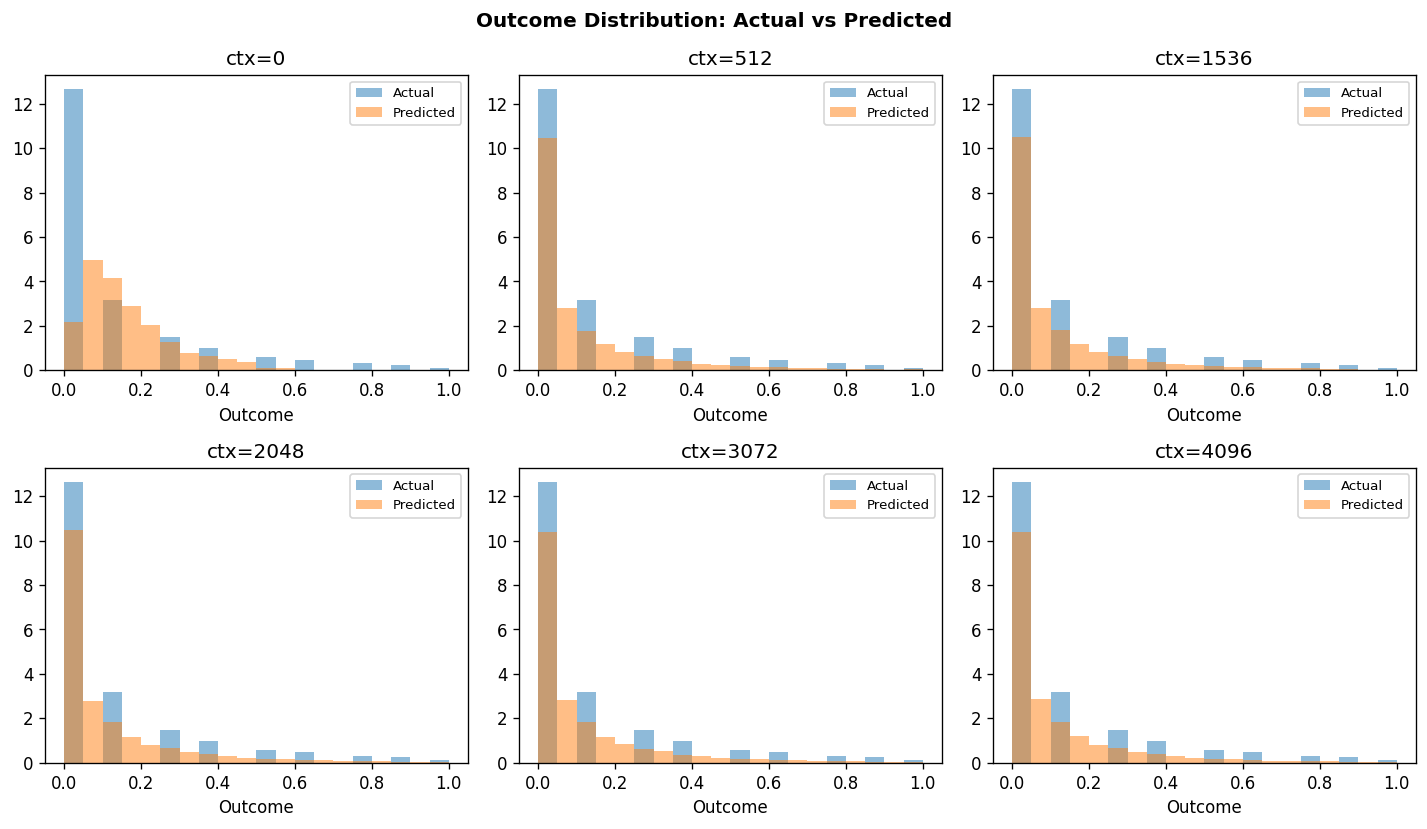

In [15]:
sub = df[df["horizon"] == 0]
contexts = sorted(sub["context"].unique())
if len(contexts) > 6:
    idx = np.linspace(0, len(contexts) - 1, 6, dtype=int)
    contexts = [contexts[i] for i in idx]

n = len(contexts)
cols = min(n, 3)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows), squeeze=False)
bins = np.linspace(0, 1, 21)
for i, c in enumerate(contexts):
    ax = axes[i // cols][i % cols]
    d = sub[sub["context"] == c]
    ax.hist(d["actual"], bins=bins, alpha=0.5, label="Actual", density=True)
    ax.hist(d["predicted"], bins=bins, alpha=0.5, label="Predicted", density=True)
    ax.set_title(f"ctx={c}")
    ax.set_xlabel("Outcome")
    ax.legend(fontsize=8)
for i in range(n, rows * cols):
    axes[i // cols][i % cols].set_visible(False)
fig.suptitle("Outcome Distribution: Actual vs Predicted", fontweight="bold")
fig.tight_layout()

## Attention analysis: what token types does the model attend to?

In [10]:
import json
import uuid
import requests

SERVER = "http://localhost:8000"
HISTORY = "../checkpoints/history.json"
CONTEXT_SIZE = 512  # number of (task, outcome) pairs to register

# Load trajectory
with open(HISTORY) as f:
    traj = json.load(f)

# Pick a target task (first eval task not in context)
TARGET_TASK = traj["tasks"][CONTEXT_SIZE]

# Register a learner with context
learner_id = str(uuid.uuid4())
requests.post(f"{SERVER}/learners", json={
    "learner_id": learner_id,
    "tasks": traj["tasks"][:CONTEXT_SIZE],
    "outcomes": traj["outcomes"][:CONTEXT_SIZE],
    "answers": traj["answers"][:CONTEXT_SIZE] if "answers" in traj else None,
}).raise_for_status()

# Get attention weights with target task
resp = requests.post(f"{SERVER}/attention", json={
    "learner_id": learner_id,
    "target_task": TARGET_TASK,
})
resp.raise_for_status()
attn = resp.json()

# Cleanup
requests.delete(f"{SERVER}/learners/{learner_id}")

print(f"Sequence length: {attn['seq_len']} tokens, {attn['n_layers']} layers, {attn['n_heads']} heads")
print(f"Target task: {TARGET_TASK[:80]}")
print(f"Token type counts: BOS={attn['token_types'].count(0)}, "
      f"TASK={attn['token_types'].count(1)}, "
      f"OUTCOME={attn['token_types'].count(2)}, "
      f"ANSWER={attn['token_types'].count(3)}")

ConnectionError: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /learners (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8000): Failed to establish a new connection: [Errno 111] Connection refused"))

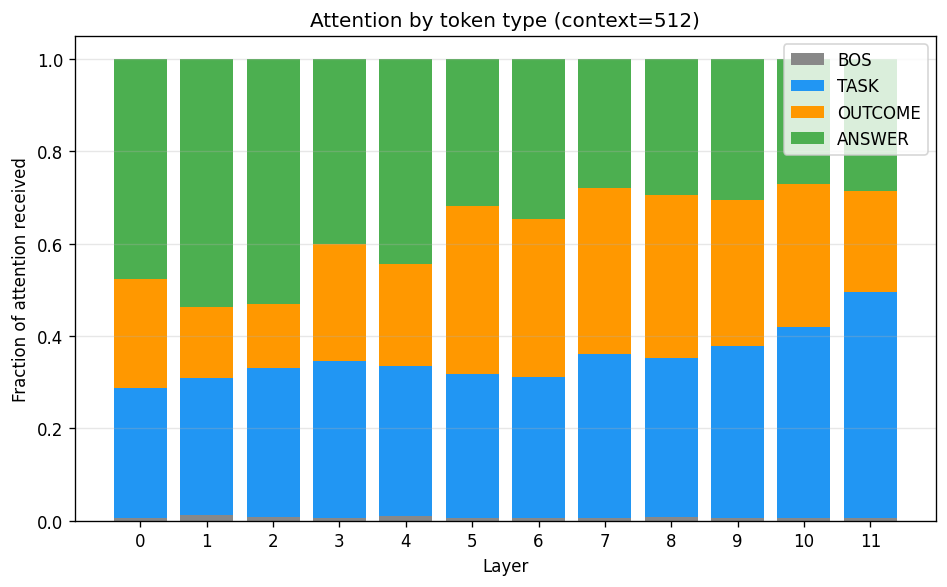

In [ ]:
# Plot: fraction of attention received by each token type, per layer
fig, ax = plt.subplots(figsize=(8, 5))

layers = list(range(attn["n_layers"]))
bottom = np.zeros(len(layers))
colors = {"BOS": "#888888", "TASK": "#2196F3", "OUTCOME": "#FF9800", "ANSWER": "#4CAF50"}

for type_name in ["BOS", "TASK", "OUTCOME", "ANSWER"]:
    vals = attn["attn_by_type"].get(type_name, [0] * len(layers))
    ax.bar(layers, vals, bottom=bottom, label=type_name, color=colors[type_name])
    bottom += np.array(vals)

ax.set_xlabel("Layer")
ax.set_ylabel("Fraction of attention received")
ax.set_title(f"Attention by token type (context={CONTEXT_SIZE})")
ax.legend()
ax.set_xticks(layers)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

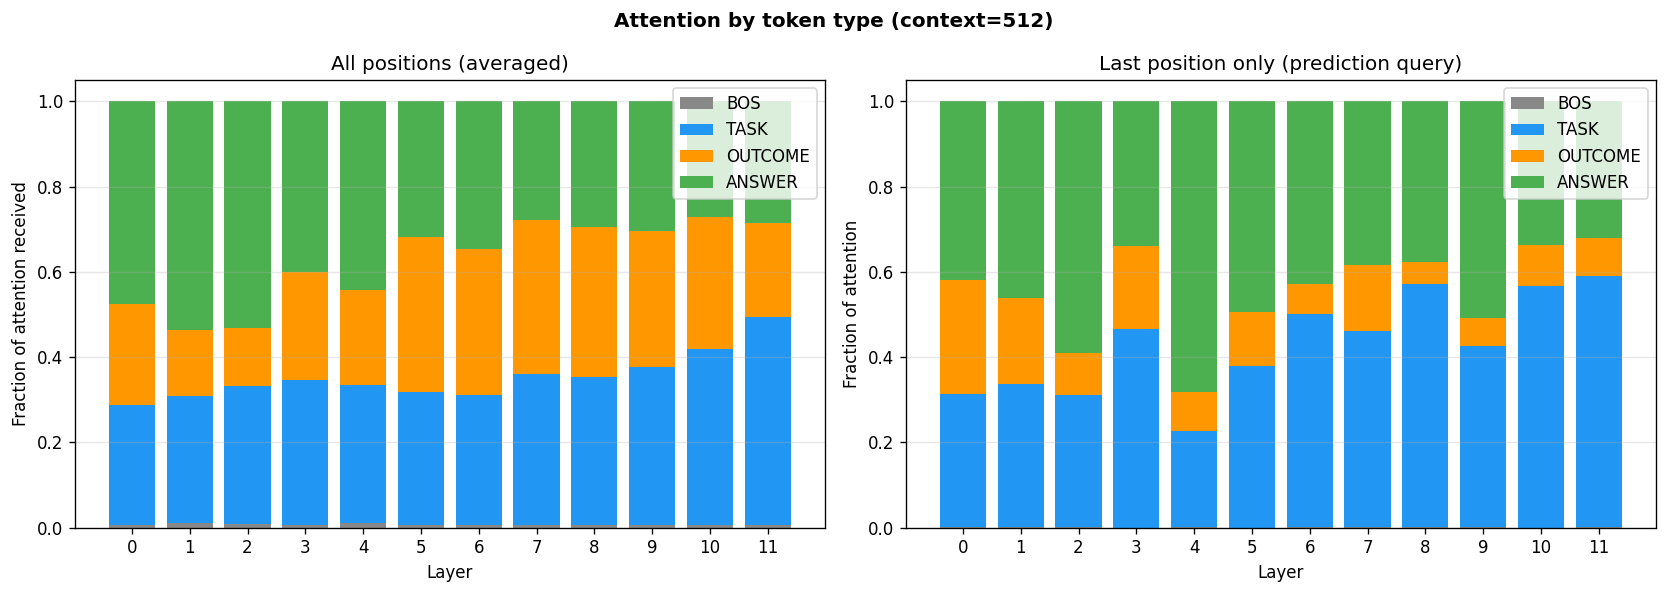

In [ ]:
# Attention from the LAST position only (the prediction position)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

layers = list(range(attn["n_layers"]))
colors = {"BOS": "#888888", "TASK": "#2196F3", "OUTCOME": "#FF9800", "ANSWER": "#4CAF50"}

# Left: all positions (same as above)
bottom = np.zeros(len(layers))
for type_name in ["BOS", "TASK", "OUTCOME", "ANSWER"]:
    vals = attn["attn_by_type"].get(type_name, [0] * len(layers))
    ax1.bar(layers, vals, bottom=bottom, label=type_name, color=colors[type_name])
    bottom += np.array(vals)
ax1.set_xlabel("Layer")
ax1.set_ylabel("Fraction of attention received")
ax1.set_title("All positions (averaged)")
ax1.legend()
ax1.set_xticks(layers)
ax1.grid(axis="y", alpha=0.3)

# Right: last position only
bottom = np.zeros(len(layers))
for type_name in ["BOS", "TASK", "OUTCOME", "ANSWER"]:
    vals = attn["last_pos_attn_by_type"].get(type_name, [0] * len(layers))
    ax2.bar(layers, vals, bottom=bottom, label=type_name, color=colors[type_name])
    bottom += np.array(vals)
ax2.set_xlabel("Layer")
ax2.set_ylabel("Fraction of attention")
ax2.set_title("Last position only (prediction query)")
ax2.legend()
ax2.set_xticks(layers)
ax2.grid(axis="y", alpha=0.3)

fig.suptitle(f"Attention by token type (context={CONTEXT_SIZE})", fontweight="bold")
fig.tight_layout()

NameError: name 'attn' is not defined

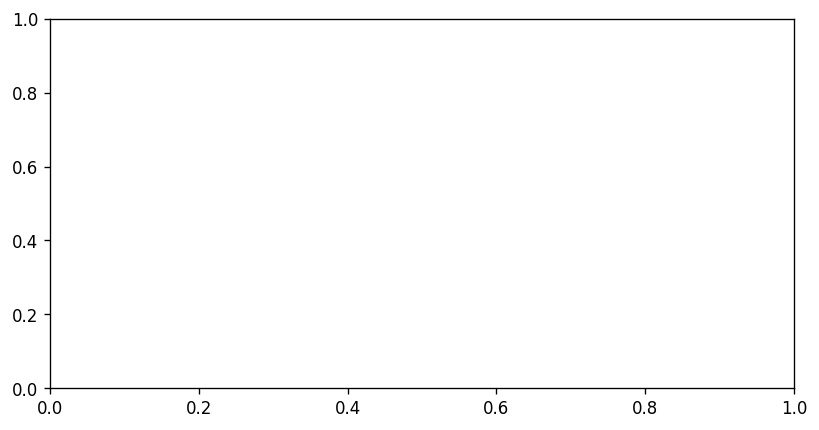

In [16]:
# How far back does attention look?
fig, ax = plt.subplots(figsize=(8, 4))

layers = list(range(attn["n_layers"]))
ax.plot(layers, attn["mean_attn_distance"], "o-", label="All positions (avg)")
ax.plot(layers, attn["last_pos_attn_distance"], "s-", label="Last position only")
ax.axhline(attn["seq_len"] / 2, color="k", ls="--", alpha=0.3, label=f"Midpoint ({attn['seq_len']//2})")
ax.set_xlabel("Layer")
ax.set_ylabel("Mean attention distance (positions)")
ax.set_title(f"Attention distance per layer (context={CONTEXT_SIZE}, seq_len={attn['seq_len']})")
ax.legend()
ax.set_xticks(layers)
ax.grid(alpha=0.3)
fig.tight_layout()

## Interactive: attention from prediction position to context (hover for details)

In [ ]:
import plotly.graph_objects as go

weights = np.array(attn["last_pos_attn_per_position"])
types = attn["token_types"]
labels = attn["token_labels"]

# Build hover text with full label and attention weight
type_map = {0: "BOS", 1: "TASK", 2: "OUTCOME", 3: "ANSWER"}
type_colors = {0: "#888888", 1: "#2196F3", 2: "#FF9800", 3: "#4CAF50"}
hover_texts = []
bar_colors = []
for i, (lbl, w, t) in enumerate(zip(labels, weights, types)):
    hover_texts.append(f"pos {i} ({type_map[t]})<br>{lbl}<br>attention: {w:.6f}")
    # Last position (target) gets a distinct color
    if lbl.startswith("TARGET:"):
        bar_colors.append("#E91E63")
    else:
        bar_colors.append(type_colors[t])

fig = go.Figure()
fig.add_trace(go.Bar(
    x=list(range(len(weights))),
    y=weights,
    marker=dict(color=bar_colors),
    hovertext=hover_texts,
    hoverinfo="text",
))

fig.update_layout(
    title=f"Attention from target task to context (context={CONTEXT_SIZE})<br>"
          f"<sub>Target: {TARGET_TASK[:80]}</sub>",
    xaxis_title="Position in sequence",
    yaxis_title="Attention weight",
    height=450,
    hoverlabel=dict(font_size=12),
)
fig.show()

## Confusion matrix: Easy / Medium / Hard classification

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

def categorize(values, thresholds=(0.1, 0.8)):
    cats = []
    for v in values:
        if v <= thresholds[0]:
            cats.append("Hard")
        elif v <= thresholds[1]:
            cats.append("Medium")
        else:
            cats.append("Easy")
    return cats

labels = ["Hard", "Medium", "Easy"]
max_ctx = df_all["context"].max()
sample = df_all[(df_all["horizon"] == 0) & (df_all["context"] == max_ctx) & (df_all["n_traj"] == n_trajs[0])]
dist = Counter(categorize(sample["actual"]))
total = len(sample)

# --- Figure 1: Actual distribution ---
fig1, ax = plt.subplots(figsize=(5, 2.5))
counts = [dist[l] for l in labels]
pcts = [dist[l] / total for l in labels]
colors = ["#d32f2f", "#ffa726", "#66bb6a"]
bars = ax.barh(labels, pcts, color=colors, edgecolor="white", height=0.6)
for bar, c, p in zip(bars, counts, pcts):
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height() / 2,
            f"{c} ({p:.0%})", va="center", fontsize=10)
ax.set_xlim(0, max(pcts) * 1.3)
ax.set_xlabel("Fraction of eval tasks")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
fig1.tight_layout()

# --- Figure 2: Confusion matrices ---
n_cols = len(n_trajs)
fig2, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4), squeeze=False)

for i, n in enumerate(n_trajs):
    ax = axes[0][i]
    sub = df_all[(df_all["n_traj"] == n) & (df_all["horizon"] == 0) & (df_all["context"] == max_ctx)]
    true_cats = categorize(sub["actual"])
    pred_cats = categorize(sub["predicted"])
    cm = confusion_matrix(true_cats, pred_cats, labels=labels)
    cm_ratio = cm / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_ratio, display_labels=labels).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_xlabel("Predicted" if i == n_cols // 2 else "")
    ax.set_ylabel("Actual" if i == 0 else "")
    ax.set_title(f"n={n}")

fig2.tight_layout()

NameError: name 'df_all' is not defined

## Scaling: performance vs number of training trajectories

Load `results{1,10,100,1000}.csv` and compare metrics across training set sizes.

In [4]:
import glob as _glob

# Load all results files
n_trajs = []
dfs = {}
for path in sorted(_glob.glob("results*.csv")):
    n = int(path.replace("results", "").replace(".csv", ""))
    n_trajs.append(n)
    d = pd.read_csv(path)
    d["error"] = np.abs(d["predicted"] - d["actual"])
    d["n_traj"] = n
    dfs[n] = d

n_trajs = sorted(n_trajs)
df_all = pd.concat(dfs.values(), ignore_index=True)
print(f"Training sizes: {n_trajs}")
print(f"Total rows: {len(df_all):,}")

Training sizes: [1, 10, 100, 1000]
Total rows: 5,070,924


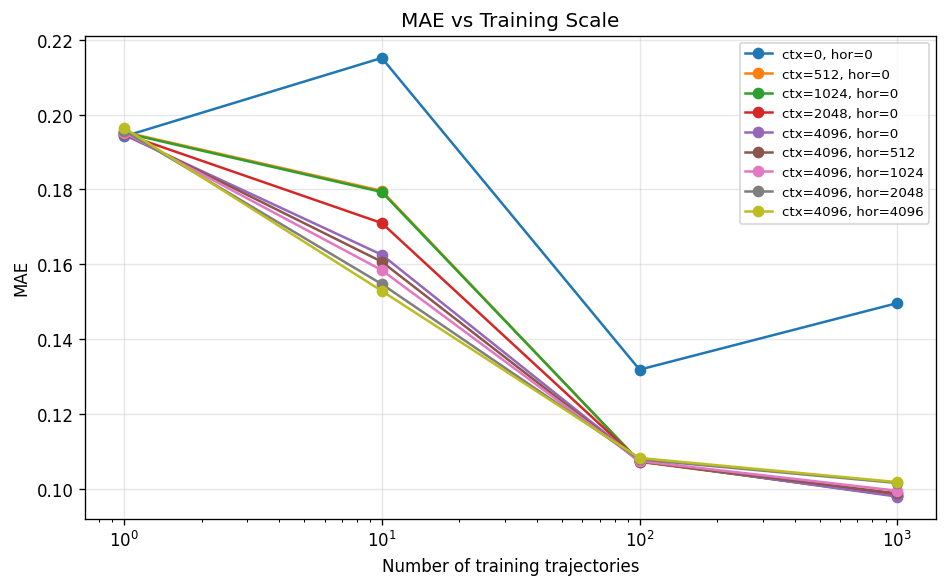

In [5]:
# MAE vs number of training trajectories, for (context, horizon) pairs
sub = df_all.copy()
pairs = [(0, 0), (512, 0), (1024, 0), (2048, 0), (4096, 0),
         (4096, 512), (4096, 1024), (4096, 2048), (4096, 4096)]
pairs = [(c, h) for c, h in pairs
         if c in sub["context"].unique() and h in sub["horizon"].unique()]

fig, ax = plt.subplots(figsize=(8, 5))
for c, h in pairs:
    d = sub[(sub["context"] == c) & (sub["horizon"] == h)]
    mae_by_n = d.groupby("n_traj")["error"].mean()
    ax.plot(mae_by_n.index, mae_by_n.values, "o-", label=f"ctx={c}, hor={h}")

ax.set_xscale("log")
ax.set_xlabel("Number of training trajectories")
ax.set_ylabel("MAE")
ax.set_title("MAE vs Training Scale")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()

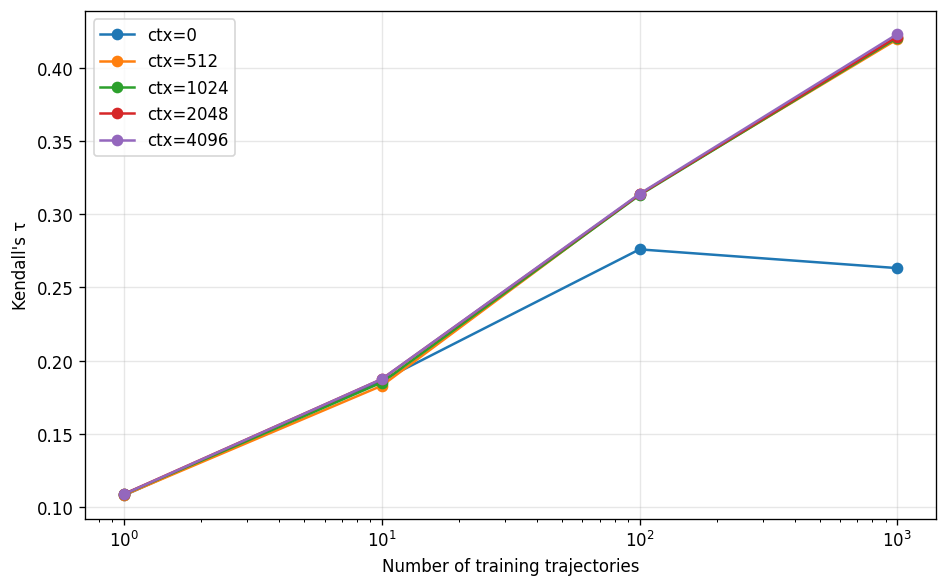

In [68]:
# Kendall tau and Pearson r vs number of training trajectories (horizon=0)
sub = df_all[df_all["horizon"] == 0]

fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))
contexts_to_show = [0, 512, 1024, 2048, 4096]

for c in contexts_to_show:
    taus, rs = [], []
    for n in n_trajs:
        d = sub[(sub["n_traj"] == n) & (sub["context"] == c)]
        taus.append(stats.kendalltau(d["actual"], d["predicted"]).statistic)
        rs.append(np.corrcoef(d["actual"], d["predicted"])[0, 1])
    ax1.plot(n_trajs, taus, "o-", label=f"ctx={c}")
    ax2.plot(n_trajs, rs, "o-", label=f"ctx={c}")

ax1.set_xscale("log")
ax1.set_xlabel("Number of training trajectories")
ax1.set_ylabel("Kendall's τ")
ax1.legend()
ax1.grid(alpha=0.3)

fig.tight_layout()

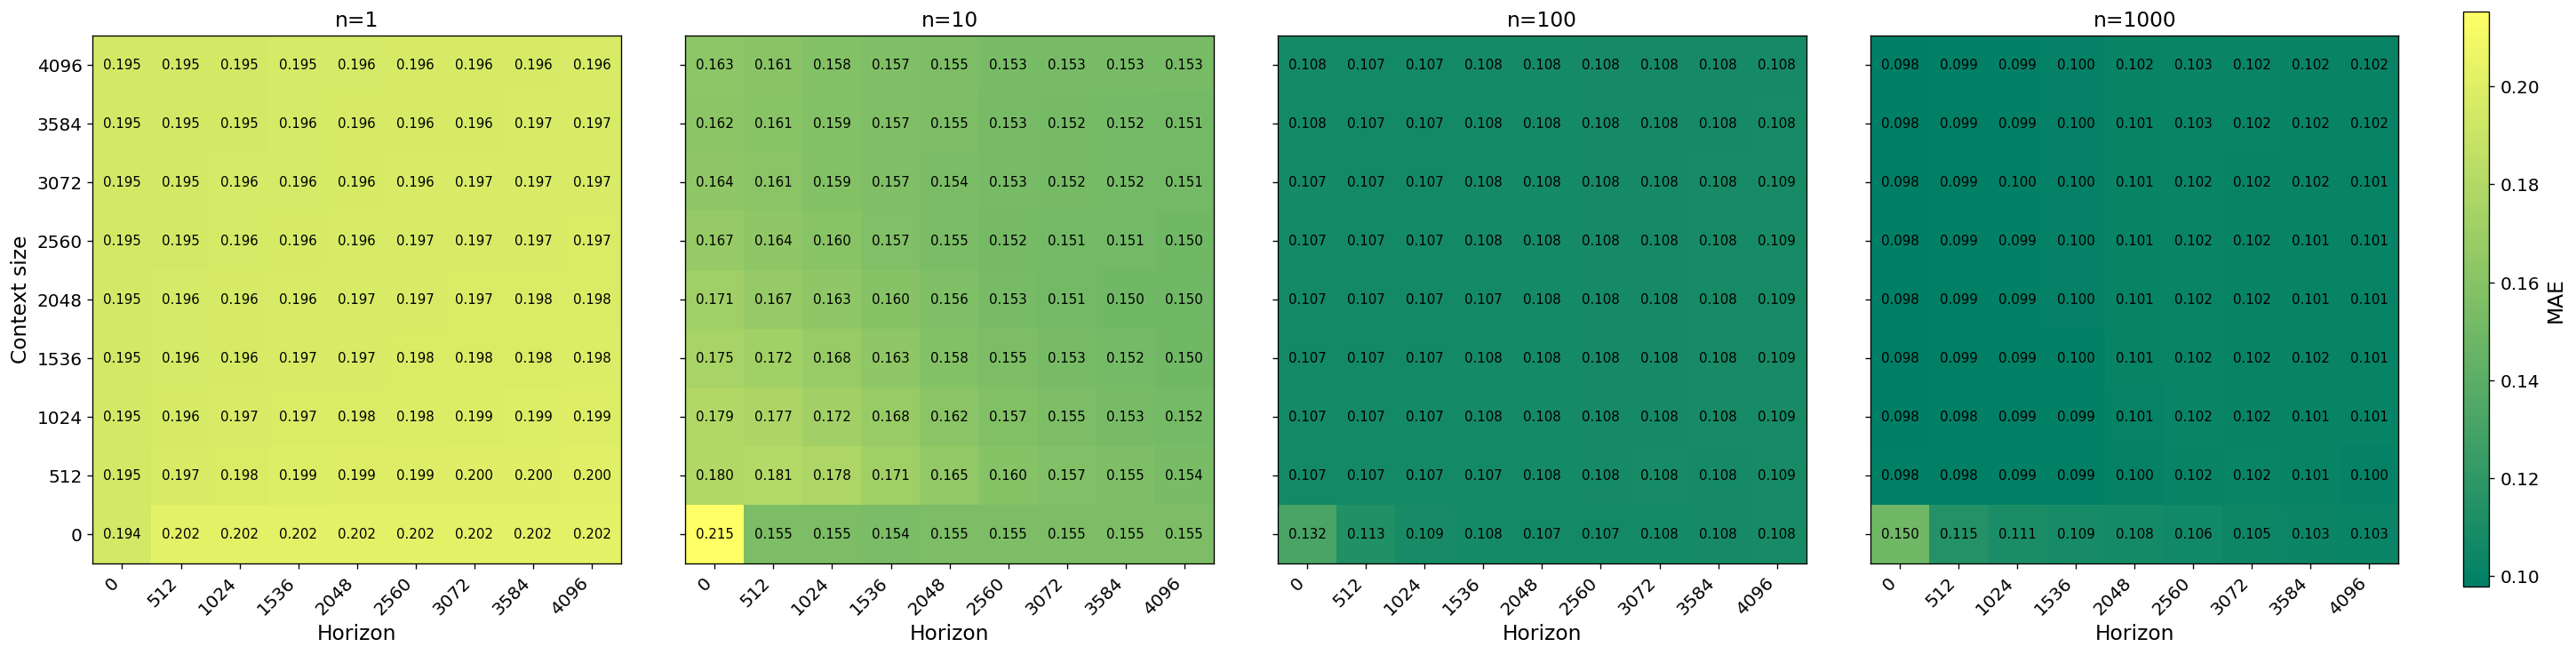

In [63]:
# MAE heatmap: context × horizon, side by side for each training scale
from matplotlib.gridspec import GridSpec

n_cols = len(n_trajs)
fig = plt.figure(figsize=(7 * n_cols + 1, 7))
gs = GridSpec(1, n_cols + 1, figure=fig, width_ratios=[1] * n_cols + [0.05], wspace=0.15)

vmin = df_all.groupby(["n_traj", "context", "horizon"])["error"].mean().min()
vmax = df_all.groupby(["n_traj", "context", "horizon"])["error"].mean().max()
median_val = (vmin + vmax) / 2

for i, n in enumerate(n_trajs):
    ax = fig.add_subplot(gs[0, i])
    d = dfs[n]
    mae = d.groupby(["context", "horizon"])["error"].mean().reset_index()
    matrix = mae.pivot(index="context", columns="horizon", values="error")
    im = ax.imshow(matrix.values, cmap="summer", aspect="equal",
                   vmin=vmin, vmax=vmax, origin="lower")
    # Annotate cells
    for ri in range(matrix.shape[0]):
        for ci in range(matrix.shape[1]):
            val = matrix.values[ri, ci]
            if not np.isnan(val):
                ax.text(ci, ri, f"{val:.3f}", ha="center", va="center",
                        fontsize=9, color="black")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, fontsize=12, rotation=45, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index if i == 0 else [], fontsize=12)
    ax.set_xlabel("Horizon", fontsize=14)
    if i == 0:
        ax.set_ylabel("Context size", fontsize=14)
    ax.set_title(f"n={n}", fontsize=14)

cax = fig.add_subplot(gs[0, -1])
# Make the text bold
cbar = fig.colorbar(im, cax=cax, label="MAE")
cbar.ax.tick_params(labelsize=12)
cbar.set_label("MAE", fontsize=14)

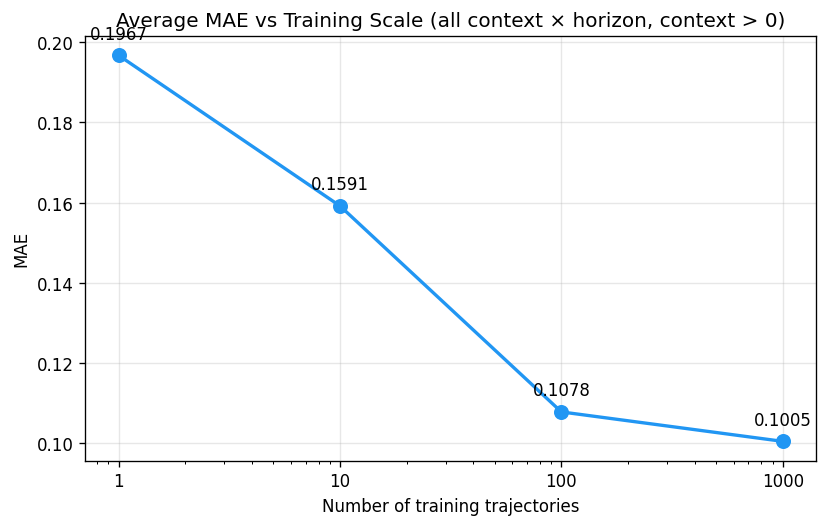

In [ ]:
# Average MAE across all (context, horizon) pairs, excluding context=0
sub = df_all[df_all["context"] > 0]
avg_mae = sub.groupby("n_traj")["error"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(avg_mae.index, avg_mae.values, "o-", color="#2196F3", markersize=8, linewidth=2)
for x, y in zip(avg_mae.index, avg_mae.values):
    ax.annotate(f"{y:.4f}", (x, y), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10)
ax.set_xscale("log")
ax.set_xticks(n_trajs)
ax.set_xticklabels(n_trajs)
ax.set_xlabel("Number of training trajectories")
ax.set_ylabel("MAE")
ax.set_title("Average MAE vs Training Scale (all context × horizon, context > 0)")
ax.grid(alpha=0.3)
fig.tight_layout()

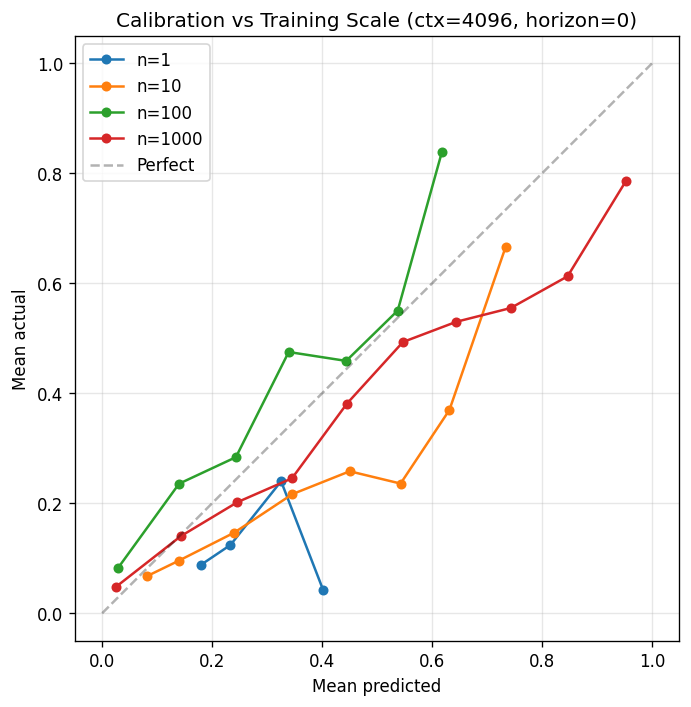

In [8]:
# Calibration comparison across training scales (horizon=0, max context)
max_ctx = df_all["context"].max()
sub = df_all[(df_all["horizon"] == 0) & (df_all["context"] == max_ctx)]

fig, ax = plt.subplots(figsize=(6, 6))
bins = np.linspace(0, 1, 11)

for n in n_trajs:
    d = sub[sub["n_traj"] == n].copy()
    d["bin"] = pd.cut(d["predicted"], bins=bins, include_lowest=True)
    cal = d.groupby("bin", observed=True).agg(
        pred_mean=("predicted", "mean"),
        actual_mean=("actual", "mean"),
        count=("actual", "count"),
    )
    cal = cal[cal["count"] >= 5]
    ax.plot(cal["pred_mean"], cal["actual_mean"], "o-", label=f"n={n}", markersize=5)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect")
ax.set_xlabel("Mean predicted")
ax.set_ylabel("Mean actual")
ax.set_title(f"Calibration vs Training Scale (ctx={max_ctx}, horizon=0)")
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
fig.tight_layout()

In [9]:
# Summary table: key metrics by training scale
rows = []
for n in n_trajs:
    d = dfs[n]
    h0 = d[d["horizon"] == 0]
    h0_max_ctx = h0[h0["context"] == h0["context"].max()]
    h0_no_ctx = h0[h0["context"] == 0]

    tau_max = stats.kendalltau(h0_max_ctx["actual"], h0_max_ctx["predicted"]).statistic
    tau_zero = stats.kendalltau(h0_no_ctx["actual"], h0_no_ctx["predicted"]).statistic
    r_max = np.corrcoef(h0_max_ctx["actual"], h0_max_ctx["predicted"])[0, 1]

    rows.append({
        "n_traj": n,
        "MAE (ctx=0)": h0_no_ctx["error"].mean(),
        "MAE (max ctx)": h0_max_ctx["error"].mean(),
        "MAE (overall)": d["error"].mean(),
        "τ (ctx=0)": tau_zero,
        "τ (max ctx)": tau_max,
        "r (max ctx)": r_max,
    })

summary = pd.DataFrame(rows).set_index("n_traj")
summary.index.name = "Training trajectories"
summary.style.format("{:.4f}").background_gradient(cmap="RdYlGn_r", axis=0)

,MAE (ctx=0),MAE (max ctx),MAE (overall),τ (ctx=0),τ (max ctx),r (max ctx)
Training trajectories,,,,,,
1,0.1942,0.1946,0.1972,0.1078,0.1087,0.1793
10,0.2152,0.1625,0.1594,0.1863,0.1873,0.2880
100,0.1318,0.1075,0.1082,0.2760,0.3139,0.4330
1000,0.1496,0.0979,0.1017,0.2632,0.4231,0.6119


## RL Agent Performance over Training Steps

Mean eval outcome at each training step, loaded from `checkpoints/rl{n}_*/step_*.json` (DFM-guided curriculum) vs `checkpoints/rl_eval_*/step_*.json` (uniform sampling baseline).

rl n=1000: 11 steps from rl1000_Qwen2.5-1.5B-Instruct_dapo_dfm_target0.5_eps0.1_bs64_lr5e-6_seed42
rl n=100: 11 steps from rl100_Qwen2.5-1.5B-Instruct_dapo_dfm_target0.5_eps0.1_bs64_lr5e-6_seed42
rl n=10: 11 steps from rl10_Qwen2.5-1.5B-Instruct_dapo_dfm_target0.5_eps0.1_bs64_lr5e-6_seed42
rl n=1: 11 steps from rl1_Qwen2.5-1.5B-Instruct_dapo_dfm_target0.5_eps0.1_bs64_lr5e-6_seed42
baseline: 11 steps from rl_eval_Qwen2.5-1.5B-Instruct_dapo


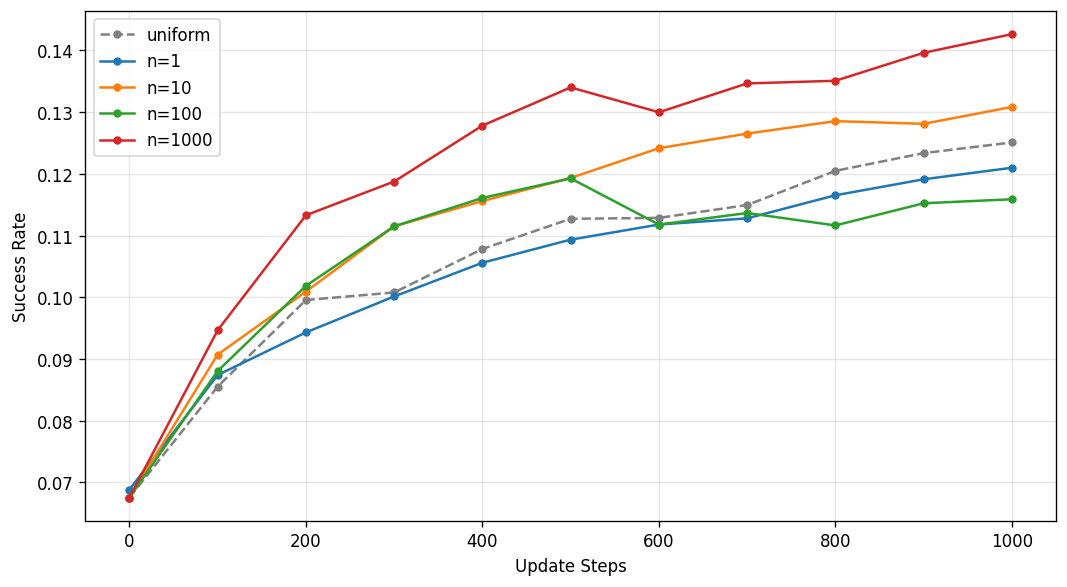

In [88]:
import json, re
from pathlib import Path

CKPT_DIR = Path("../checkpoints")

def load_learning_curve(run_dir: Path) -> dict[int, float]:
    """Load step_*.json files, return {step: mean_outcome}."""
    curve = {}
    for p in run_dir.glob("step_*.json"):
        step = int(re.search(r"step_(\d+)", p.name).group(1))
        with open(p) as f:
            data = json.load(f)
        curve[step] = np.mean(data["outcomes"])
    return dict(sorted(curve.items()))

# Load DFM-guided runs (rl{n}_*)
rl_curves = {}
for d in sorted(CKPT_DIR.iterdir()):
    m = re.match(r"^rl(\d+)_", d.name)
    if m and d.is_dir():
        n = int(m.group(1))
        rl_curves[n] = load_learning_curve(d)
        print(f"rl n={n}: {len(rl_curves[n])} steps from {d.name}")

# Load baseline (uniform sampling)
baseline_curves = {}
for d in sorted(CKPT_DIR.iterdir()):
    if d.name.startswith("rl_eval_") and d.is_dir():
        baseline_curves[d.name] = load_learning_curve(d)
        print(f"baseline: {len(baseline_curves[d.name])} steps from {d.name}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

for name, curve in baseline_curves.items():
    steps, vals = zip(*curve.items())
    ax.plot(steps, vals, "o--", color="gray", markersize=4, label="uniform")

for n in sorted(rl_curves):
    curve = rl_curves[n]
    steps, vals = zip(*curve.items())
    ax.plot(steps, vals, "o-", markersize=4, label=f"n={n}")

ax.set_xlabel("Update Steps")
ax.set_ylabel("Success Rate")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

In [ ]:
df = pd.read_csv("../checkpoints/sampled_sr.csv")
df.head()

,Step,1000 - critic/score/mean,1000 - critic/score/mean__MIN,1000 - critic/score/mean__MAX,100 - critic/score/mean,100 - critic/score/mean__MIN,100 - critic/score/mean__MAX,10 - critic/score/mean,10 - critic/score/mean__MIN,10 - critic/score/mean__MAX,1 - critic/score/mean,1 - critic/score/mean__MIN,1 - critic/score/mean__MAX,Uniform - critic/score/mean,Uniform - critic/score/mean__MIN,Uniform - critic/score/mean__MAX
0,1,0.169922,0.169922,0.169922,0.158203,0.158203,0.158203,0.105469,0.105469,0.105469,0.052734,0.052734,0.052734,0.062500,0.062500,0.062500
1,2,0.265625,0.265625,0.265625,0.119141,0.119141,0.119141,0.146484,0.146484,0.146484,0.046875,0.046875,0.046875,0.103516,0.103516,0.103516
2,3,0.279297,0.279297,0.279297,0.072266,0.072266,0.072266,0.187500,0.187500,0.187500,0.085938,0.085938,0.085938,0.076172,0.076172,0.076172
3,4,0.205078,0.205078,0.205078,0.119141,0.119141,0.119141,0.128906,0.128906,0.128906,0.074219,0.074219,0.074219,0.125000,0.125000,0.125000
4,5,0.318359,0.318359,0.318359,0.111328,0.111328,0.111328,0.095703,0.095703,0.095703,0.080078,0.080078,0.080078,0.054688,0.054688,0.054688


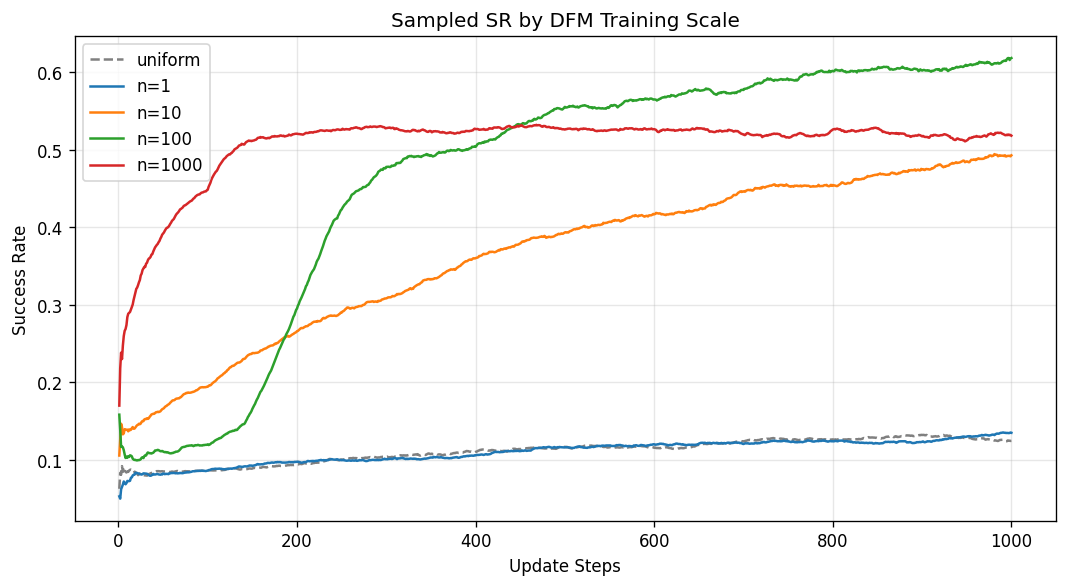

In [87]:
uniform = np.array(df['Uniform - critic/score/mean'])
traj1 = np.array(df['1 - critic/score/mean'])
traj10 = np.array(df['10 - critic/score/mean'])
traj100 = np.array(df['100 - critic/score/mean'])
traj1000 = np.array(df['1000 - critic/score/mean'])
steps = np.array(df['Step'])

# Smooth with rolling mean for readability
window = 100
def smooth(x):
    return pd.Series(x).rolling(window, min_periods=1).mean().values

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(steps, smooth(uniform), color="gray", ls="--", label="uniform")
ax.plot(steps, smooth(traj1), label="n=1")
ax.plot(steps, smooth(traj10), label="n=10")
ax.plot(steps, smooth(traj100), label="n=100")
ax.plot(steps, smooth(traj1000), label="n=1000")

ax.set_xlabel("Update Steps")
ax.set_ylabel("Success Rate")
ax.set_title("Sampled SR by DFM Training Scale")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()